# 📘 Session 13: Descriptive Statistics, Distributions, and Correlation
### Duration: ~2.5 Hours

---

**Topics Covered:**
1. Describing Data — Central Tendency and Spread
2. Percentiles, Quantiles, and Outliers
3. Shape of Distributions — Skewness and Kurtosis
4. Common Distributions and Normality Checks
5. Correlation — Pearson, Spearman, and Kendall

---

**Why This Session Matters for Data Science:**
- **EDA and reporting** start with concise numeric summaries before any modeling
- **Feature scaling and transforms** depend on spread, skew, and outliers
- **Model assumptions** (e.g., linear models on residuals) often tie to distribution shape
- **Multicollinearity** and redundant features show up first in correlation structure

> After visual EDA (Sessions 11–12), this session adds the **quantitative** lens: centers, spread, distribution shape, and how variables co-vary.

**Libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn`, and **`scipy`** (install with `pip install scipy` if you see `ModuleNotFoundError`).


---
## 1. Describing Data — Central Tendency and Spread

Summaries answer: *What are typical values, and how much do they vary?*

### Central tendency and spread (numeric)

| Measure | Meaning | Pandas / NumPy |
|---------|---------|----------------|
| **Mean** | Arithmetic average | `s.mean()`, `np.mean()` |
| **Median** | 50th percentile (robust to outliers) | `s.median()`, `np.median()` |
| **Mode** | Most frequent | `s.mode()` |
| **Variance** | Average squared deviation | `s.var()`, `np.var()` |
| **Std dev** | Spread in original units | `s.std()`, `np.std()` |
| **Range** | Max − min | `s.max() - s.min()` |

### Quick profile: `describe()`

`DataFrame.describe()` gives count, mean, std, min, quartiles, max for numeric columns.

| Option | Purpose |
|--------|---------|
| `percentiles=[0.05, 0.5, 0.95]` | Custom quantiles in the table |
| `include='all'` | Numeric + categorical stats in one call |

> ⚠️ **Special Case — pandas vs NumPy variance**: pandas uses `ddof=1` (sample) by default; NumPy uses `ddof=0` (population). Be explicit: `np.var(x, ddof=1)`.

> **Data Science relevance**: Means dominate dashboards; **median** and **IQR** often suit skewed revenue or latency. Choose based on the decision, not habit.


In [7]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

np.random.seed(42)
n = 500
df = pd.DataFrame({
    "score": np.random.normal(75, 10, n),
    "revenue": np.random.lognormal(3, 1.2, n),
    "region": np.random.choice(
        ["North", "South", "East", "West"], n, p=[0.35, 0.25, 0.25, 0.15]
    ),
})

print(df.head())
print()
print("Numeric describe():")
print(df.describe())

print("\nCustom percentiles:")
print(df[["score", "revenue"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

print("\nMean / median / std of revenue by region:")
print(df.groupby("region")["revenue"].agg(["mean", "median", "std"]))


       score     revenue region
0  79.967142   61.032900  North
1  73.617357  198.601433  North
2  81.476885    3.749862   East
3  90.230299   39.470876   East
4  72.658466    9.200234  North

Numeric describe():
            score     revenue
count  500.000000  500.000000
mean    75.068380   41.428220
std      9.812532   62.190248
min     42.587327    0.789572
25%     67.996926    9.832252
50%     75.127971   20.785133
75%     81.367833   43.881512
max    113.527315  472.887955

Custom percentiles:
            score     revenue
count  500.000000  500.000000
mean    75.068380   41.428220
std      9.812532   62.190248
min     42.587327    0.789572
5%      59.846000    3.099484
25%     67.996926    9.832252
50%     75.127971   20.785133
75%     81.367833   43.881512
95%     91.288053  164.494342
max    113.527315  472.887955

Mean / median / std of revenue by region:
             mean     median        std
region                                 
East    41.574640  19.263189  70.244106
Nor

---
## 2. Percentiles, Quantiles, and Outliers

| Term | Meaning |
|------|---------|
| **Quantile** | Value below fraction *q* of the data |
| **IQR** | Q3 − Q1 |
| **Tukey fences** | Q1 − 1.5×IQR and Q3 + 1.5×IQR (box-plot rule of thumb) |

Outliers are **context-dependent** — a large sale may be signal, not noise.

| Method | When to use |
|--------|-------------|
| IQR rule | Fast EDA, aligns with box plots |
| Z-scores | Rough checks when distribution is near symmetric |
| Multivariate methods | Later: isolation forest, robust covariance, etc. |

> ⚠️ **Special Case — interpolation**: `quantile()` uses linear interpolation between points; tiny samples yield coarse steps.

> **Data Science relevance**: Clipping, winsorizing, or log transforms often follow from how you treat tails — document the rule you use.


Q1=9.83, Q3=43.88, IQR=34.05
Tukey fences: [-41.24, 94.96]
Outside fences: 51 rows (10.2%)


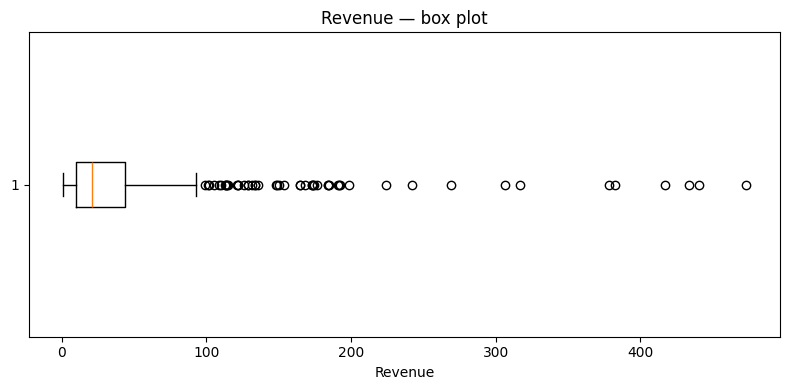

In [2]:
# --- IQR and box plot ---
s = df["revenue"]
q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out_mask = (s < low) | (s > high)

print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Tukey fences: [{low:.2f}, {high:.2f}]")
print(f"Outside fences: {out_mask.sum()} rows ({100 * out_mask.mean():.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(s, vert=False)
ax.set_title("Revenue — box plot")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.show()


---
## 3. Shape — Skewness and Kurtosis

| Measure | Meaning |
|---------|---------|
| **Skewness** | Asymmetry: positive → longer right tail |
| **Excess kurtosis** | (Kurtosis − 3) vs normal; **normal has excess = 0** |

| API | Notes |
|-----|-------|
| `Series.skew()`, `Series.kurtosis()` | pandas: excess kurtosis by default |
| `stats.skew(x, bias=False)` | SciPy skew |
| `stats.kurtosis(x, fisher=True, bias=False)` | `fisher=True` → excess kurtosis |

> ⚠️ **Small samples**: Skew/kurtosis estimates are noisy — pair with histograms or KDE.

> **Data Science relevance**: Heavy right skew often motivates **`log1p`** or **`sqrt`** before linear models or distance-based methods.


score: skew=0.1802, excess kurtosis=0.2711
revenue: skew=3.7558, excess kurtosis=17.7817


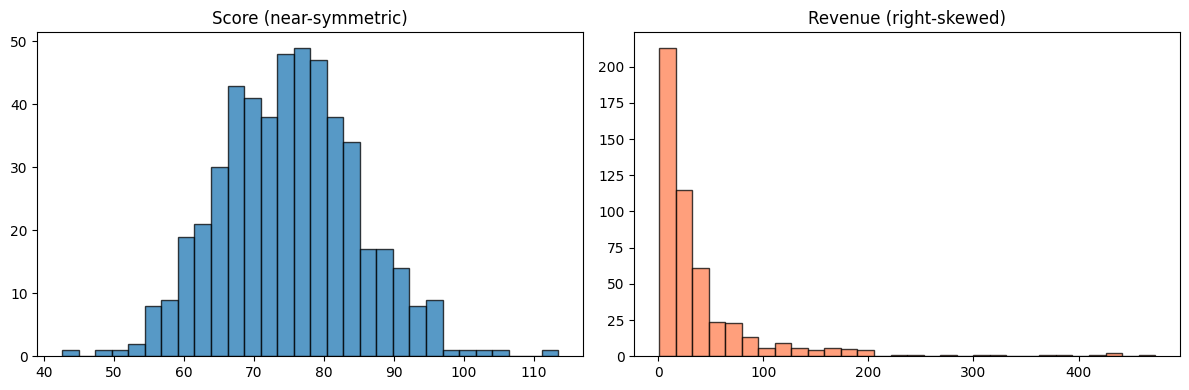

In [3]:
for col in ["score", "revenue"]:
    x = df[col]
    print(f"{col}: skew={x.skew():.4f}, excess kurtosis={x.kurtosis():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["score"], bins=30, edgecolor="black", alpha=0.75)
axes[0].set_title("Score (near-symmetric)")
axes[1].hist(df["revenue"], bins=30, edgecolor="black", alpha=0.75, color="coral")
axes[1].set_title("Revenue (right-skewed)")
plt.tight_layout()
plt.show()


---
## 4. Distributions and Normality Checks

You rarely *prove* normality; you check whether deviations matter for the method.

| Tool | Role |
|------|------|
| Histogram / KDE | Visual shape |
| **Q–Q plot** | Compare ordered data to normal quantiles (`stats.probplot`) |
| **Shapiro–Wilk** | Common test; very sensitive when *n* is large |
| **`normaltest`** | D'Agostino–Pearson; combines skew and kurtosis |

| Distribution | Typical use (conceptual) |
|--------------|-------------------------|
| Normal | Aggregated noise; residuals (sometimes) |
| Lognormal | Positive sizes, prices, incomes |
| Poisson | Event counts per interval |

> ⚠️ **Large *n***: Tests often reject for trivial non-normality — rely on plots and effect sizes too.

> **Data science note**: Tree ensembles often care little about feature normality; **linear models**, **ANOVA**, and some **tests** do.


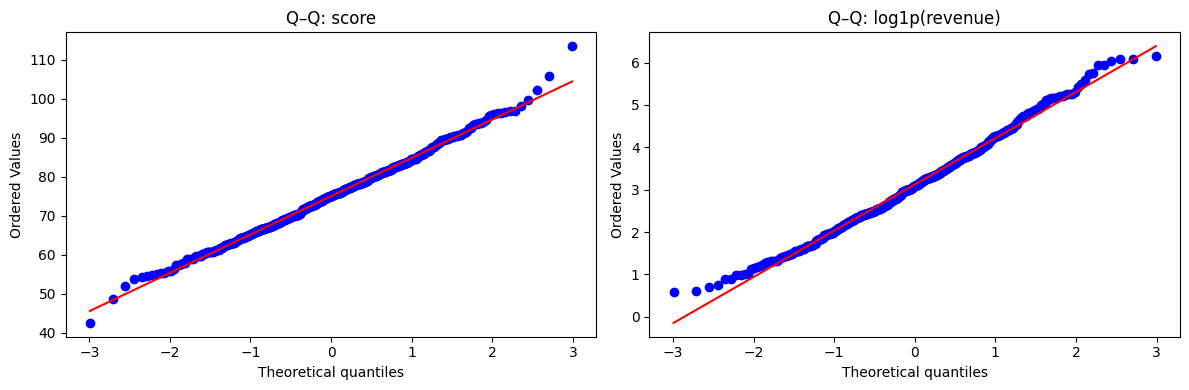

Shapiro–Wilk (score): W=0.9967, p=4.0127e-01
D'Agostino–Pearson (score): K2=4.2235, p=1.2103e-01


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(df["score"], dist="norm", plot=axes[0])
axes[0].set_title("Q–Q: score")
stats.probplot(np.log1p(df["revenue"]), dist="norm", plot=axes[1])
axes[1].set_title("Q–Q: log1p(revenue)")
plt.tight_layout()
plt.show()

x = df["score"].values
if len(x) <= 5000:
    sw_stat, sw_p = stats.shapiro(x)
    print(f"Shapiro–Wilk (score): W={sw_stat:.4f}, p={sw_p:.4e}")

k2, p_nt = stats.normaltest(x)
print(f"D'Agostino–Pearson (score): K2={k2:.4f}, p={p_nt:.4e}")


---
## 5. Correlation — Pearson, Spearman, Kendall

| Method | Measures | Best when |
|--------|----------|-----------|
| **Pearson** | Linear association | Roughly linear, few extreme outliers |
| **Spearman** | Monotonic (rank) | Ordinal data, outliers, mild nonlinearity |
| **Kendall** | Concordance of pairs | Small samples; interpret with ties |

**Remember:** correlation **≠** causation; watch **confounders** and **multiple comparisons** when scanning many pairs.

| pandas | |
|--------|--|
| `df.corr()` | Default Pearson |
| `df.corr(method="spearman")` | Rank-based matrix |

> ⚠️ **Encoded categories**: Pearson between arbitrary integer codes is meaningless — use appropriate associations for mixed types.

> **Data science relevance**: High |r| among features → consider regularization, VIF, PCA, or dropping redundant columns for linear models.


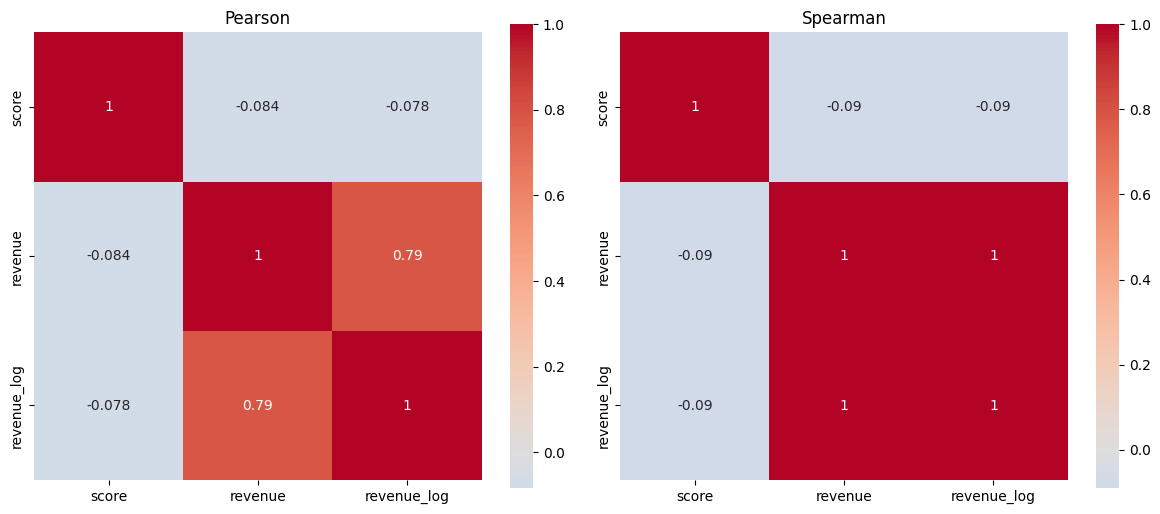

Pearson score vs revenue: r=-0.0837, p-value=6.1418e-02


In [5]:
df_num = df[["score", "revenue"]].copy()
df_num["revenue_log"] = np.log1p(df["revenue"])

pearson = df_num.corr(method="pearson")
spearman = df_num.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(pearson, annot=True, cmap="coolwarm", center=0, ax=axes[0], square=True)
axes[0].set_title("Pearson")
sns.heatmap(spearman, annot=True, cmap="coolwarm", center=0, ax=axes[1], square=True)
axes[1].set_title("Spearman")
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(df["score"], df["revenue"])
print(f"Pearson score vs revenue: r={r:.4f}, p-value={p:.4e}")


---
## 🧪 Practice Exercises

1. On any numeric DataFrame column, print `describe()` with custom 5th, 50th, and 95th percentiles.
2. Compute Tukey fences for one column; list counts outside — decide (in words) drop vs cap vs keep.
3. Plot a column before and after `log1p`; compare skewness.
4. Q–Q plot for a z-scored column `(x - mean) / std` — interpret tail behavior.
5. Find two variables with **non-linear** monotone relationship; compare Pearson vs Spearman.
6. **Spurious correlation demo**: draw two independent `Normal(0,1)` series with `n=25` and `n=2000`; note how often |r| is “surprisingly” large when *n* is small.
7. `groupby` a category: report mean and median of a numeric column per group — when is median safer?
8. Load `sns.load_dataset("penguins")`, drop NA, plot a **numeric-only** correlation heatmap.

---

## 📝 Session 13 Summary

| Topic | Key takeaway |
|-------|--------------|
| **Descriptive stats** | Centers, spread, and `describe()` anchor numeric EDA |
| **Percentiles / IQR** | Robust spread; Tukey fences for screening |
| **Skew / kurtosis** | Guide transforms |
| **Normality** | Plots + tests; interpret with sample size |
| **Correlation** | Pearson vs Spearman vs Kendall; not causation |

### Key Gotchas
- pandas vs NumPy **ddof** for variance/std
- Normality tests **over-reject** at large *n*
- Pearson on **arbitrary category codes** is invalid
- Pairwise **r** misses nonlinear structure — other tools later (e.g. mutual information)

### Next Session
**Session 14**: Exploratory Data Analysis (EDA) — structured workflow from quality audit through multivariate exploration.
